# 02 — Mô hình 1 (TextCNN) và Mô hình 2 (BiLSTM)

Hai mô hình "from scratch" theo yêu cầu đề bài:

| # | Họ | Kiến trúc |
|---|---|---|
| 1 | CNN-based | TextCNN: Conv1D đa kernel + max-pool cho mỗi câu, ghép `[u; v; abs(u-v); u*v]` |
| 2 | RNN/LSTM/GRU | BiLSTM chia sẻ trọng số + attention pooling, cùng công thức ghép |

Notebook này **không định nghĩa lại kiến trúc hay vòng lặp train** — mọi thứ nằm trong
`src/models.py` và `src/trainer.py` để đảm bảo notebook và `python src/train.py` cho ra
cùng một kết quả (yêu cầu tái lập ở Phụ lục A).

Chạy `01_eda.ipynb` trước để có `data/splits/*.csv`.

## Setup Kaggle — kéo code từ GitHub

Chạy cell này **trước tiên** trên Kaggle. Bỏ qua được khi chạy ở máy local.
Sửa code ở máy → `git push` → chạy lại cell này để lấy bản mới.

In [1]:
import os

REPO_URL = "https://github.com/dofu18/ViANLI_DL_NLP.git"

if os.path.exists("/kaggle/input"):
    !rm -rf /kaggle/working/repo
    !git clone -q $REPO_URL /kaggle/working/repo
    !cp -r /kaggle/working/repo/src /kaggle/working/
    !cp -r /kaggle/working/repo/configs /kaggle/working/
    !cp -r /kaggle/working/repo/data /kaggle/working/     # split cố định từ 01_eda
    print("src/:", sorted(os.listdir("/kaggle/working/src")))
else:
    print("Chạy local — bỏ qua bước clone.")

src/: ['data.py', 'evaluate.py', 'models.py', 'train.py', 'trainer.py']


In [2]:
# SEGMENT=True ở dưới chỉ có tác dụng khi underthesea đã được cài. Kaggle không
# cài sẵn -> lần chạy trước vocab được xây trên text CHƯA tách từ.
!pip install -q underthesea

import json, os, sys, time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ON_KAGGLE = os.path.exists("/kaggle/input")
ROOT = "/kaggle/working" if ON_KAGGLE else os.path.abspath("..")
sys.path.insert(0, os.path.join(ROOT, "src"))

FIG_DIR = os.path.join(ROOT, "outputs", "figures")
LOG_DIR = os.path.join(ROOT, "outputs", "logs")
CKPT_DIR = os.path.join(ROOT, "outputs", "checkpoints")
for d in (FIG_DIR, LOG_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

from data import (LABELS, Vocab, build_embedding_matrix, load_splits,
                  make_loaders, set_seed)
from models import BiLSTMNLI, TextCNNNLI, count_params
from trainer import predict, train_model
from evaluate import (error_examples, full_report, plot_confusion_matrix,
                      plot_learning_curve)

SEED = 42
set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.5 MB/s eta 0:00:00
device = cuda | Tesla T4


## 1. Nạp split cố định

Ưu tiên `data/splits/*.csv` do `01_eda.ipynb` sinh ra — đảm bảo cả 4 mô hình dùng
đúng cùng một phân chia. Nếu chưa có thì gọi lại `load_splits()`.

In [3]:
SPLIT_DIR = os.path.join(ROOT, "data", "splits")
COLS = {"premise": "premise", "hypothesis": "hypothesis", "label": "label"}

def load_from_csv():
    ds = {}
    for name in ("train", "validation", "test"):
        df = pd.read_csv(os.path.join(SPLIT_DIR, f"{name}.csv"), encoding="utf-8")
        df["premise"] = df["premise"].fillna("")
        df["hypothesis"] = df["hypothesis"].fillna("")
        # dict-of-list: khớp interface mà NLIPairDataset mong đợi
        ds[name] = {c: df[c].tolist() for c in ("premise", "hypothesis", "label")}
    return ds, COLS

if os.path.exists(os.path.join(SPLIT_DIR, "train.csv")):
    ds, cols = load_from_csv()
    print("Nạp từ data/splits/ (split cố định)")
else:
    hf_ds, cols = load_splits(seed=SEED)
    ds = {k: {c: list(v[cols[c]]) for c in cols} for k, v in hf_ds.items()}
    cols = COLS
    print("CẢNH BÁO: chưa có data/splits/ — chạy 01_eda.ipynb trước để cố định split")

{k: len(v["label"]) for k, v in ds.items()}

Nạp từ data/splits/ (split cố định)


{'train': 8012, 'validation': 1000, 'test': 1000}

## 2. Vocab — chỉ xây từ TRAIN

Xây vocab từ dev/test là một dạng rò rỉ. `Vocab.build()` chỉ nhận văn bản của train.

In [4]:
SEGMENT = True     # tách từ tiếng Việt bằng underthesea
from data import word_segment
_probe = word_segment("Tọa đàm được tổ chức tại Hà Nội", strict=False)
assert not SEGMENT or "_" in _probe, (
    f"SEGMENT=True nhưng tách từ không chạy ({_probe!r}). "
    "Cài underthesea rồi restart kernel, hoặc đặt SEGMENT=False và ghi rõ trong báo cáo.")
print("Tách từ:", _probe)
MIN_FREQ = 2
MAX_LEN = 128      # chốt lại theo p95 trong 01_eda.ipynb
EMB_DIM = 300

t0 = time.time()
vocab = Vocab.build(ds["train"]["premise"] + ds["train"]["hypothesis"],
                    min_freq=MIN_FREQ, segment=SEGMENT)
vocab.save(os.path.join(CKPT_DIR, "shared_vocab.txt"))
print(f"|V| = {len(vocab)}  ({time.time() - t0:.1f}s)")
print("20 token đầu:", vocab.itos[:20])

[word_segment] backend = underthesea
Tách từ: Tọa_đàm được tổ_chức tại Hà_Nội
|V| = 9503  (18.6s)
20 token đầu: ['<pad>', '<unk>', '.', ',', 'và', 'của', 'được', 'trong', 'là', 'có', 'các', 'đã', '"', 'cho', 'người', '/', 'với', 'một', '-', 'ở']


## 3. Embedding PhoW2V

Tải [PhoW2V 300 chiều](https://github.com/datquocnguyen/PhoW2V) và upload thành Kaggle
Dataset, hoặc đặt `EMB_PATH = None` để chạy nhánh random init (nhánh ablation).

In [5]:
EMB_PATH = None   # ví dụ: "/kaggle/input/phow2v/word2vec_vi_words_300dims.txt"

if EMB_PATH and os.path.exists(EMB_PATH):
    emb_matrix = build_embedding_matrix(vocab, EMB_PATH, EMB_DIM)
else:
    emb_matrix = None
    print("Không có PhoW2V -> khởi tạo embedding ngẫu nhiên. "
          "Ghi rõ điều này trong báo cáo (mục ablation).")

Không có PhoW2V -> khởi tạo embedding ngẫu nhiên. Ghi rõ điều này trong báo cáo (mục ablation).


## 4. Hàm chạy một thí nghiệm

Dùng chung cho cả TextCNN, BiLSTM và mọi nhánh ablation — tránh lệch giao thức.

In [6]:
BASE_CFG = {
    "seed": SEED,
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "clip_grad": 5.0,
    "early_stopping_patience": 5,
    "class_weights": None,   # bật nếu 01_eda cho thấy nhãn lệch mạnh
}

PRED_DIR = os.path.join(LOG_DIR, "predictions")
os.makedirs(PRED_DIR, exist_ok=True)

RESULTS = {}


def save_preds(run_name, y_true, y_pred):
    """Ghi dự đoán NGAY sau mỗi run, không đợi tới cuối notebook.

    Notebook này chạy 5-6 run trong 1-2 giờ; Save & Run All chết ở run cuối mà chỉ
    ghi npy ở cell cuối thì mất sạch dự đoán của các run đã xong.
    """
    np.save(os.path.join(PRED_DIR, f"{run_name}.npy"), y_pred)
    y_true_path = os.path.join(PRED_DIR, "y_true.npy")
    y_true = np.asarray(y_true)
    if os.path.exists(y_true_path):
        assert np.array_equal(np.load(y_true_path), y_true), (
            "y_true lệch so với file đã lưu — thứ tự test set không nhất quán giữa "
            "các mô hình, mọi so sánh chéo ở nb 05 sẽ sai.")
    else:
        np.save(y_true_path, y_true)


def run(run_name, arch, *, dropout=0.5, hypothesis_only=False,
        pretrained_emb=emb_matrix, max_len=MAX_LEN, **overrides):
    """Train + đánh giá một cấu hình; lưu log/hình/checkpoint và trả về summary."""
    set_seed(SEED)   # reset seed trước MỖI thí nghiệm để so sánh công bằng
    cfg = {**BASE_CFG, **overrides, "run_name": run_name, "arch": arch,
           "dropout": dropout, "max_length": max_len,
           "hypothesis_only": hypothesis_only,
           "segment": SEGMENT,
           "pretrained_emb": "phow2v" if pretrained_emb is not None else "none"}

    common = dict(vocab_size=len(vocab), emb_dim=EMB_DIM, dropout=dropout,
                  pretrained_emb=pretrained_emb)
    if arch == "textcnn":
        model = TextCNNNLI(n_filters=cfg.get("n_filters", 128),
                           kernel_sizes=tuple(cfg.get("kernel_sizes", (2, 3, 4, 5))),
                           **common)
    elif arch == "bilstm":
        model = BiLSTMNLI(hidden=cfg.get("hidden", 256),
                          num_layers=cfg.get("num_layers", 1), **common)
    else:
        raise ValueError(arch)

    loaders = make_loaders(ds, cols, vocab, batch_size=cfg["batch_size"],
                           max_len=max_len, segment=SEGMENT,
                           hypothesis_only=hypothesis_only,
                           num_workers=2 if ON_KAGGLE else 0)

    print(f"\n=== {run_name} | {arch} | {count_params(model):,} tham số | "
          f"tách từ = {SEGMENT} ===")
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    started = time.time()
    model, history = train_model(
        model, loaders, cfg, device=DEVICE,
        log_path=os.path.join(LOG_DIR, f"{run_name}_history.json"))
    elapsed = time.time() - started

    y_true, y_pred = predict(model, loaders["test"], DEVICE)
    save_preds(run_name, y_true, y_pred)

    # Thời gian suy luận cho §Chi phí tính toán. Đo cùng cách với nb 03 và 04
    # (chạy lại predict trên toàn test rồi chia cho số mẫu) để bảng chi phí của
    # cả 4 mô hình so sánh được với nhau.
    t1 = time.time()
    predict(model, loaders["test"], DEVICE)
    ms_per_sample = (time.time() - t1) / len(y_true) * 1000

    report = full_report(y_true, y_pred,
                         out_json=os.path.join(LOG_DIR, f"{run_name}_test.json"))
    plot_learning_curve(history, run_name,
                        os.path.join(FIG_DIR, f"{run_name}_curve.png"))
    plot_confusion_matrix(y_true, y_pred, run_name,
                          os.path.join(FIG_DIR, f"{run_name}_cm.png"))
    os.makedirs(os.path.join(CKPT_DIR, run_name), exist_ok=True)
    torch.save(model.state_dict(), os.path.join(CKPT_DIR, run_name, "best.pt"))

    summary = {"run_name": run_name, "arch": arch,
               "accuracy": report["accuracy"], "macro_f1": report["macro_f1"],
               "weighted_f1": report["weighted_f1"],
               "params": count_params(model),
               "epochs_chạy": len(history),
               "train_seconds": round(elapsed, 1),
               "inference_ms_per_sample": round(ms_per_sample, 2),
               "peak_vram_gb": (round(torch.cuda.max_memory_allocated() / 1024 ** 3, 2)
                                if DEVICE == "cuda" else None),
               "word_segment": SEGMENT}
    with open(os.path.join(LOG_DIR, f"{run_name}_summary.json"), "w",
              encoding="utf-8") as f:
        json.dump({**summary, "config": cfg}, f, ensure_ascii=False, indent=2)
    RESULTS[run_name] = {**summary, "_preds": (y_true, y_pred), "_history": history}
    print(json.dumps(summary, ensure_ascii=False, indent=2))
    return summary

## 5. Mô hình 1 — TextCNN

In [7]:
run("textcnn", "textcnn")


=== textcnn | textcnn | 4,440,663 tham số | tách từ = True ===
epoch   1 | loss 1.1573 | val_acc 0.3880 | val_macroF1 0.3374
epoch   2 | loss 0.9558 | val_acc 0.3640 | val_macroF1 0.2892
epoch   3 | loss 0.6514 | val_acc 0.3790 | val_macroF1 0.3299
epoch   4 | loss 0.3224 | val_acc 0.3530 | val_macroF1 0.3457
epoch   5 | loss 0.1809 | val_acc 0.3230 | val_macroF1 0.2918
epoch   6 | loss 0.1101 | val_acc 0.3160 | val_macroF1 0.3085
epoch   7 | loss 0.0661 | val_acc 0.3300 | val_macroF1 0.3150
epoch   8 | loss 0.0286 | val_acc 0.3280 | val_macroF1 0.3272
epoch   9 | loss 0.0092 | val_acc 0.3250 | val_macroF1 0.3224
Early stopping ở epoch 9 (best macro-F1 dev = 0.3457)
{
  "run_name": "textcnn",
  "arch": "textcnn",
  "accuracy": 0.334,
  "macro_f1": 0.32742772998527475,
  "weighted_f1": 0.3274929241261722,
  "params": 4440663,
  "epochs_chạy": 9,
  "train_seconds": 120.7,
  "inference_ms_per_sample": 1.67,
  "peak_vram_gb": 0.16,
  "word_segment": true
}


{'run_name': 'textcnn',
 'arch': 'textcnn',
 'accuracy': 0.334,
 'macro_f1': 0.32742772998527475,
 'weighted_f1': 0.3274929241261722,
 'params': 4440663,
 'epochs_chạy': 9,
 'train_seconds': 120.7,
 'inference_ms_per_sample': 1.67,
 'peak_vram_gb': 0.16,
 'word_segment': True}

## 6. Mô hình 2 — BiLSTM + attention

In [8]:
run("bilstm_attn", "bilstm")


=== bilstm_attn | bilstm | 5,045,848 tham số | tách từ = True ===
epoch   1 | loss 1.1501 | val_acc 0.4000 | val_macroF1 0.3813
epoch   2 | loss 0.8950 | val_acc 0.3590 | val_macroF1 0.3479
epoch   3 | loss 0.5176 | val_acc 0.3620 | val_macroF1 0.3630
epoch   4 | loss 0.2085 | val_acc 0.3550 | val_macroF1 0.3543
epoch   5 | loss 0.0658 | val_acc 0.3550 | val_macroF1 0.3539
epoch   6 | loss 0.0194 | val_acc 0.3450 | val_macroF1 0.3417
Early stopping ở epoch 6 (best macro-F1 dev = 0.3813)
{
  "run_name": "bilstm_attn",
  "arch": "bilstm",
  "accuracy": 0.379,
  "macro_f1": 0.3658715199945178,
  "weighted_f1": 0.3659529492457316,
  "params": 5045848,
  "epochs_chạy": 6,
  "train_seconds": 85.1,
  "inference_ms_per_sample": 1.78,
  "peak_vram_gb": 0.51,
  "word_segment": true
}


{'run_name': 'bilstm_attn',
 'arch': 'bilstm',
 'accuracy': 0.379,
 'macro_f1': 0.3658715199945178,
 'weighted_f1': 0.3659529492457316,
 'params': 5045848,
 'epochs_chạy': 6,
 'train_seconds': 85.1,
 'inference_ms_per_sample': 1.78,
 'peak_vram_gb': 0.51,
 'word_segment': True}

## 7. Ablation

Đề bài yêu cầu phân tích **ít nhất một** yếu tố; ở đây chạy bốn nhánh trên cùng
kiến trúc BiLSTM (rẻ, nhanh) để bảng ablation có chiều sâu.

| Nhánh | Câu hỏi |
|---|---|
| `no_pretrained_emb` | PhoW2V đóng góp bao nhiêu? |
| `hypothesis_only` | Mô hình đoán được nhãn khi **không** nhìn premise? → đo bias |
| `dropout_0.2` | Regularization ảnh hưởng thế nào trên bộ adversarial? |
| `maxlen_64` | Cắt ngắn đầu vào có mất thông tin không? |

Bỏ bớt nhánh nếu hết quota GPU — nhưng phải **ghi rõ trong báo cáo** nhánh nào đã bỏ.

In [9]:
if emb_matrix is not None:
    run("bilstm_no_pretrained_emb", "bilstm", pretrained_emb=None)
else:
    print("Bỏ qua: baseline vốn đã dùng embedding ngẫu nhiên.")

Bỏ qua: baseline vốn đã dùng embedding ngẫu nhiên.


In [10]:
run("bilstm_hyponly", "bilstm", hypothesis_only=True)


=== bilstm_hyponly | bilstm | 5,045,848 tham số | tách từ = True ===
epoch   1 | loss 1.1535 | val_acc 0.3840 | val_macroF1 0.3532
epoch   2 | loss 0.9450 | val_acc 0.3880 | val_macroF1 0.3666
epoch   3 | loss 0.6235 | val_acc 0.3440 | val_macroF1 0.3435
epoch   4 | loss 0.2335 | val_acc 0.3380 | val_macroF1 0.3362
epoch   5 | loss 0.0978 | val_acc 0.3310 | val_macroF1 0.3283
epoch   6 | loss 0.0384 | val_acc 0.3450 | val_macroF1 0.3412
epoch   7 | loss 0.0106 | val_acc 0.3360 | val_macroF1 0.3327
Early stopping ở epoch 7 (best macro-F1 dev = 0.3666)
{
  "run_name": "bilstm_hyponly",
  "arch": "bilstm",
  "accuracy": 0.351,
  "macro_f1": 0.3405392900422157,
  "weighted_f1": 0.34059988069567637,
  "params": 5045848,
  "epochs_chạy": 7,
  "train_seconds": 55.6,
  "inference_ms_per_sample": 0.84,
  "peak_vram_gb": 0.51,
  "word_segment": true
}


{'run_name': 'bilstm_hyponly',
 'arch': 'bilstm',
 'accuracy': 0.351,
 'macro_f1': 0.3405392900422157,
 'weighted_f1': 0.34059988069567637,
 'params': 5045848,
 'epochs_chạy': 7,
 'train_seconds': 55.6,
 'inference_ms_per_sample': 0.84,
 'peak_vram_gb': 0.51,
 'word_segment': True}

In [11]:
run("bilstm_dropout02", "bilstm", dropout=0.2)
run("bilstm_maxlen64", "bilstm", max_len=64)


=== bilstm_dropout02 | bilstm | 5,045,848 tham số | tách từ = True ===
epoch   1 | loss 1.1412 | val_acc 0.4180 | val_macroF1 0.4101
epoch   2 | loss 0.8733 | val_acc 0.3640 | val_macroF1 0.3423
epoch   3 | loss 0.4502 | val_acc 0.3370 | val_macroF1 0.3371
epoch   4 | loss 0.1722 | val_acc 0.3530 | val_macroF1 0.3533
epoch   5 | loss 0.0527 | val_acc 0.3510 | val_macroF1 0.3500
epoch   6 | loss 0.0128 | val_acc 0.3520 | val_macroF1 0.3526
Early stopping ở epoch 6 (best macro-F1 dev = 0.4101)
{
  "run_name": "bilstm_dropout02",
  "arch": "bilstm",
  "accuracy": 0.403,
  "macro_f1": 0.39631024297287226,
  "weighted_f1": 0.3963818471684021,
  "params": 5045848,
  "epochs_chạy": 6,
  "train_seconds": 82.6,
  "inference_ms_per_sample": 1.7,
  "peak_vram_gb": 0.51,
  "word_segment": true
}

=== bilstm_maxlen64 | bilstm | 5,045,848 tham số | tách từ = True ===
epoch   1 | loss 1.1511 | val_acc 0.3970 | val_macroF1 0.3732
epoch   2 | loss 0.8971 | val_acc 0.3500 | val_macroF1 0.3414
epoch   3

{'run_name': 'bilstm_maxlen64',
 'arch': 'bilstm',
 'accuracy': 0.38,
 'macro_f1': 0.36213914162814786,
 'weighted_f1': 0.36223318805352994,
 'params': 5045848,
 'epochs_chạy': 6,
 'train_seconds': 79.8,
 'inference_ms_per_sample': 1.66,
 'peak_vram_gb': 0.32,
 'word_segment': True}

## 8. Tổng hợp

In [12]:
table = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in RESULTS.values()
]).sort_values("accuracy", ascending=False)
display(table.round(4))
table.to_csv(os.path.join(LOG_DIR, "cnn_rnn_results.csv"), index=False)

,run_name,arch,accuracy,macro_f1,weighted_f1,params,epochs_chạy,train_seconds,inference_ms_per_sample,peak_vram_gb,word_segment
3,bilstm_dropout02,bilstm,0.403,0.3963,0.3964,5045848,6,82.6,1.70,0.51,True
4,bilstm_maxlen64,bilstm,0.380,0.3621,0.3622,5045848,6,79.8,1.66,0.32,True
1,bilstm_attn,bilstm,0.379,0.3659,0.3660,5045848,6,85.1,1.78,0.51,True
2,bilstm_hyponly,bilstm,0.351,0.3405,0.3406,5045848,7,55.6,0.84,0.51,True
0,textcnn,textcnn,0.334,0.3274,0.3275,4440663,9,120.7,1.67,0.16,True


In [13]:
# predictions/*.npy đã được save_preds() ghi ngay sau từng run. Cell này chỉ kiểm lại.
pred_dir = os.path.join(LOG_DIR, "predictions")
missing = [n for n in RESULTS if not os.path.exists(os.path.join(pred_dir, f"{n}.npy"))]
assert not missing, f"Thiếu file dự đoán của: {missing}"

y_true_saved = np.load(os.path.join(pred_dir, "y_true.npy"))
for name, r in RESULTS.items():
    saved = np.load(os.path.join(pred_dir, f"{name}.npy"))
    assert np.array_equal(saved, r["_preds"][1]), f"{name}.npy lệch với kết quả trong RESULTS"
    acc = float((saved == y_true_saved).mean())
    assert abs(acc - r["accuracy"]) < 1e-9, (
        f"{name}: accuracy trong summary ({r['accuracy']}) không khớp với npy ({acc})")
    print(f"{name:24s} acc={acc:.4f}  tách từ={r['word_segment']}  OK")

print("\n", sorted(os.listdir(pred_dir)))

textcnn                  acc=0.3340  tách từ=True  OK
bilstm_attn              acc=0.3790  tách từ=True  OK
bilstm_hyponly           acc=0.3510  tách từ=True  OK
bilstm_dropout02         acc=0.4030  tách từ=True  OK
bilstm_maxlen64          acc=0.3800  tách từ=True  OK

 ['bilstm_attn.npy', 'bilstm_dropout02.npy', 'bilstm_hyponly.npy', 'bilstm_maxlen64.npy', 'textcnn.npy', 'y_true.npy']


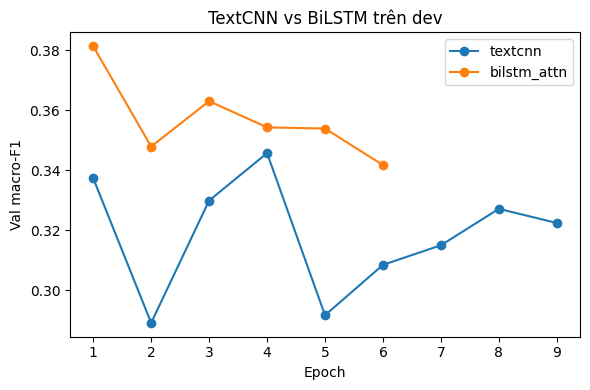

In [14]:
# Learning curve của 2 mô hình chính đặt chung một trục để so sánh
fig, ax = plt.subplots(figsize=(6, 4))
for name in ("textcnn", "bilstm_attn"):
    if name in RESULTS:
        h = RESULTS[name]["_history"]
        ax.plot([r["epoch"] for r in h], [r["val_macro_f1"] for r in h],
                marker="o", label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val macro-F1")
ax.set_title("TextCNN vs BiLSTM trên dev")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cnn_vs_rnn_dev.png"), dpi=150)
plt.show()

## 9. Xem nhanh vài lỗi

Phân tích lỗi đầy đủ nằm ở `05_analysis.ipynb`; đây chỉ là kiểm tra nhanh xem mô hình
có sập về dự đoán một nhãn duy nhất hay không.

In [15]:
best = table.iloc[0]["run_name"]
y_true, y_pred = RESULTS[best]["_preds"]
print(f"Mô hình tốt nhất: {best}")
print("Phân bố dự đoán:",
      {LABELS[i]: int((y_pred == i).sum()) for i in range(len(LABELS))})

pd.set_option("display.max_colwidth", 100)
pd.DataFrame(error_examples(ds["test"], cols, y_true, y_pred, n=10))

Mô hình tốt nhất: bilstm_dropout02
Phân bố dự đoán: {'entailment': 414, 'neutral': 363, 'contradiction': 223}


,premise,hypothesis,gold,pred
0,"Sáng 23/5, ông Trần Văn Vịnh, Chủ tịch UBND phường Mai Động, cho biết lý do phong tỏa là nam sin...",Theo thông tin một công chức Nhà nước ở phường Mai Động đã có ít nhất 11 nam sinh đã bị mắc Covi...,contradiction,entailment
1,"Sau khi xem xét camera giám sát trong khu vực, cảnh sát nhận định nạn nhân đã bị cướp tài sản và...",Cảnh sát đã phán đoán bằng nhận định sắc bén sau khi xem camera an ninh.,neutral,entailment
2,"3h sáng cùng ngày, trái tim của của người hiến đã đập lại trong lồng ngực chàng trai.","3am, một người được tái sinh.",contradiction,entailment
3,"Ông Phạm Cao Vỹ, chủ tịch Hiệp hội Du lịch Sa Pa chia sẻ, nhận được lời kêu gọi từ hiệp hội, rất...",Ông Phạm Cao Vỹ được yêu thích.,neutral,entailment
4,"Ngành y tế Quảng Nam ngày 16/5 ghi nhận 3.070 mẫu xét nghiệm âm tính nCoV, 476 mẫu đang chờ kết ...",Giữa tháng 5 số lượng mẫu âm tính tại Quảng Nam rất cao và cao thứ 2 cả nước.,neutral,entailment
5,"3h sáng cùng ngày, trái tim của của người hiến đã đập lại trong lồng ngực chàng trai.","Trái tim,một sự sống tái sinh vào 3h sáng.",neutral,entailment
6,"Theo Vogue, đôi dép của Questlove mạ vàng 24 carat, giúp nhạc sĩ Mỹ tạo nét khác biệt.",Đôi dép của nhạc sĩ tên Mỹ được làm từ vàng 24 carat.,contradiction,neutral
7,"Đang nóng ruột vì chưa biết làm thế nào để bay về sớm với hai con gái bị tai nạn, anh Trần Văn H...",Anh Trần Văn Hải không có ý định hỏi vé từ một người lạ.,neutral,contradiction
8,Hàng ngàn ly sữa đã được cộng đồng chung tay cùng Vinamilk và Quỹ sữa Vươn cao Việt Nam góp tặng...,Vinamilk đã kêu gọi cộng đồng cùng Quỹ sữa Vươn cao Việt Nam quyên góp cho chiến dịch thiện nguyện.,neutral,contradiction
9,Tỷ phú Jack Ma đã tránh hiện diện trước công chúng kể từ khi có bài phát biểu vào tháng 10/2020 ...,"Sau bài phát biểu tháng 10/2020 tại Thượng Hải, công chúng không thể bắt gặp Jack Ma.",neutral,contradiction


## Cần điền vào báo cáo

- Bảng cấu hình mô hình 1 & 2 (kiến trúc, số tham số, regularization, loss).
- Bảng siêu tham số (batch, epoch, lr, optimizer, scheduler, early stopping).
- Hình: `textcnn_curve.png`, `bilstm_attn_curve.png`, `cnn_vs_rnn_dev.png`, hai confusion matrix.
- Bảng ablation từ `cnn_rnn_results.csv`.

**Cảnh báo diễn giải:** ViANLI là bộ adversarial. Nếu TextCNN/BiLSTM chỉ nhỉnh hơn
majority baseline vài điểm, đó là kết quả hợp lệ — hai kiến trúc này không có cross-attention
giữa premise và hypothesis nên gần như không suy luận được. Hãy trình bày và giải thích,
đừng cố tinh chỉnh để "đẹp số".